# XGBoost

# 1. Imports

In [1]:
import os
import random
import io
import json
import pickle
import time
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    f1_score,
    precision_recall_curve,
    recall_score,
    roc_auc_score,
)

# 2. Config

In [2]:
DATA_DIR   = Path("../../preprocessed")
OUTPUT_DIR = Path("models/xgboost")
SEED       = 42
EARLY_STOP = 50

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# 3. Load Preprocessed Data and Metadata

In [3]:
print("Loading preprocessed data …")
with open(DATA_DIR / "column_metadata.pkl", "rb") as f:
    meta = pickle.load(f)

target = meta["target"]

train = pd.read_csv(DATA_DIR / "train.csv")
val   = pd.read_csv(DATA_DIR / "val.csv")
test  = pd.read_csv(DATA_DIR / "test.csv")

feature_cols = [c for c in train.columns if c != target]

X_train, y_train = train[feature_cols].values, train[target].values
X_val,   y_val   = val[feature_cols].values,   val[target].values
X_test,  y_test  = test[feature_cols].values,  test[target].values

neg, pos         = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"  Train: {len(y_train):,}  |  fraud rate: {y_train.mean():.3%}")
print(f"  Val  : {len(y_val):,}  |  fraud rate: {y_val.mean():.3%}")
print(f"  scale_pos_weight = {scale_pos_weight:.1f}")

dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=list(feature_cols))
dval   = xgb.DMatrix(X_val,   label=y_val,   feature_names=list(feature_cols))
dtest  = xgb.DMatrix(X_test,  label=y_test,  feature_names=list(feature_cols))

Loading preprocessed data …
  Train: 472,443  |  fraud rate: 3.499%
  Val  : 29,516  |  fraud rate: 3.500%
  scale_pos_weight = 27.6


# 4. Checkpointing

In [4]:
class PRaucCallback(xgb.callback.TrainingCallback):
    def __init__(self, dval, y_val, output_dir, log_interval=50):
        self.dval         = dval
        self.y_val        = y_val
        self.output_dir   = Path(output_dir)
        self.log_interval = log_interval

        self.best_val_pr  = 0.0
        self.best_round   = 0
        self.best_model   = None

        self.history      = {"round": [], "train_logloss": [], "val_pr_auc": [], "time_s": []}
        self._t0          = None

        print(f"\n  {'Round':>6}  {'Train Loss':>10}  {'Val PR-AUC':>10}  {'Time':>7}")
        print(f"  {'-'*6}  {'-'*10}  {'-'*10}  {'-'*7}")

    def before_training(self, model):
        self._t0 = time.time()
        return model

    def after_iteration(self, model, epoch, evals_log):
        elapsed    = time.time() - self._t0
        self._t0   = time.time()

        train_loss = evals_log.get("train", {}).get("logloss", [None])[-1]
        val_probs  = model.predict(self.dval)
        val_pr     = average_precision_score(self.y_val, val_probs)

        if val_pr > self.best_val_pr:
            self.best_val_pr = val_pr
            self.best_round  = epoch + 1
            tmp_path = self.output_dir / "_best_checkpoint.ubj"
            model.save_model(str(tmp_path))
            self.best_model = str(tmp_path)

        self.history["round"].append(epoch + 1)
        self.history["train_logloss"].append(round(train_loss, 4) if train_loss else None)
        self.history["val_pr_auc"].append(round(val_pr, 4))
        self.history["time_s"].append(round(elapsed, 1))

        marker = " ◀ best" if val_pr >= self.best_val_pr else ""
        if (epoch + 1) % self.log_interval == 0 or marker:
            print(
                f"  {epoch+1:>6}  "
                f"{train_loss:>10.4f}  "
                f"{val_pr:>10.4f}  "
                f"{elapsed:>6.1f}s"
                f"{marker}"
            )

        pd.DataFrame(self.history).to_csv(
            self.output_dir / "training_log.csv", index=False
        )
        return False

    def after_training(self, model):
        print(f"\n  Best val PR-AUC: {self.best_val_pr:.4f} at round {self.best_round}")
        return model

# 5. Training

In [5]:
t0 = time.time()

print(f"\n{'='*60}")
print("Training XGBoost with PR-AUC tracking and best checkpointing")
print(f"{'='*60}")

params = {
    "objective":        "binary:logistic",
    "eval_metric":      ["logloss", "auc"],
    "tree_method":      "hist",
    "seed":             SEED,
    "deterministic_histogram": True,
    "verbosity":        0,
    "scale_pos_weight": scale_pos_weight,
    "max_depth":        6,
    "learning_rate":    0.05,
    "min_child_weight": 5,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "gamma":            1.0,
    "reg_alpha":        0.1,
    "reg_lambda":       1.0,
}

callback = PRaucCallback(dval=dval, y_val=y_val, output_dir=OUTPUT_DIR)

model = xgb.train(
    params,
    dtrain,
    num_boost_round       = 1000,
    evals                 = [(dtrain, "train"), (dval, "val")],
    early_stopping_rounds = EARLY_STOP,
    callbacks             = [callback],
    verbose_eval          = False,
)

best_model = xgb.Booster()
best_model.load_model(callback.best_model)
model = best_model

history = callback.history
best_val_pr = callback.best_val_pr

print(f"  Restored best model from round {callback.best_round}")
print(f"\nTotal training time: {time.time()-t0:.1f}s")



Training XGBoost with PR-AUC tracking and best checkpointing

   Round  Train Loss  Val PR-AUC     Time
  ------  ----------  ----------  -------
       1      0.6739      0.3538     1.1s ◀ best
       2      0.6567      0.3890     0.1s ◀ best
       3      0.6409      0.3916     0.1s ◀ best
       6      0.6003      0.4081     0.1s ◀ best
       7      0.5887      0.4233     0.1s ◀ best
       8      0.5779      0.4358     0.1s ◀ best
      10      0.5574      0.4427     0.2s ◀ best
      11      0.5484      0.4444     0.1s ◀ best
      12      0.5402      0.4452     0.1s ◀ best
      13      0.5320      0.4477     0.1s ◀ best
      14      0.5246      0.4498     0.1s ◀ best
      15      0.5174      0.4506     0.1s ◀ best
      16      0.5104      0.4551     0.1s ◀ best
      17      0.5038      0.4569     0.1s ◀ best
      18      0.4975      0.4586     0.1s ◀ best
      19      0.4913      0.4598     0.1s ◀ best
      20      0.4858      0.4617     0.1s ◀ best
      21      0.4805

# 6. Evaluation

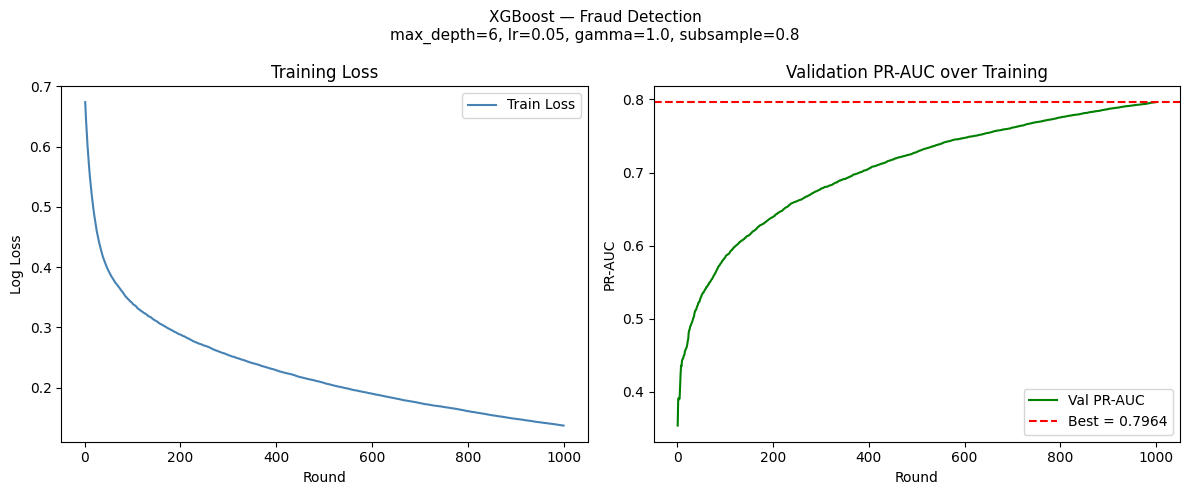

Training curves saved to models/xgboost/xgb_training_curves.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(history["round"], history["train_logloss"], label="Train Loss", color="steelblue")
ax.set_xlabel("Round")
ax.set_ylabel("Log Loss")
ax.set_title("Training Loss")
ax.legend()

ax = axes[1]
ax.plot(history["round"], history["val_pr_auc"], label="Val PR-AUC", color="green")
ax.axhline(
    y=best_val_pr, color="red", linestyle="--",
    label=f"Best = {best_val_pr:.4f}"
)
ax.set_xlabel("Round")
ax.set_ylabel("PR-AUC")
ax.set_title("Validation PR-AUC over Training")
ax.legend()

cfg_label = (
    f"max_depth={params['max_depth']}, lr={params['learning_rate']}, "
    f"gamma={params['gamma']}, subsample={params['subsample']}"
)
plt.suptitle(f"XGBoost — Fraud Detection\n{cfg_label}", fontsize=11)
plt.tight_layout()

curves_path = OUTPUT_DIR / "xgb_training_curves.png"
plt.savefig(curves_path, dpi=150)
plt.show()
print(f"Training curves saved to {curves_path}")


In [7]:
val_probs = model.predict(dval)
val_auc   = roc_auc_score(y_val, val_probs)
val_pr    = average_precision_score(y_val, val_probs)

print(f"\n{'='*50}")
print(f"  Checkpoint PR-AUC (recall deferred to PR curve)")
print(f"{'='*50}")
print(f"  Val  PR-AUC : {val_pr:.4f}")
print(f"  Val  ROC-AUC: {val_auc:.4f}")

test_probs = model.predict(dtest)
test_auc   = roc_auc_score(y_test, test_probs)
test_pr    = average_precision_score(y_test, test_probs)

print(f"\n{'='*50}")
print(f"  Checkpoint PR-AUC (recall deferred to PR curve)")
print(f"{'='*50}")
print(f"  Test PR-AUC : {test_pr:.4f}")
print(f"  Test ROC-AUC: {test_auc:.4f}")


  Checkpoint PR-AUC (recall deferred to PR curve)
  Val  PR-AUC : 0.7964
  Val  ROC-AUC: 0.9664

  Checkpoint PR-AUC (recall deferred to PR curve)
  Test PR-AUC : 0.7886
  Test ROC-AUC: 0.9671


# 7. Plots

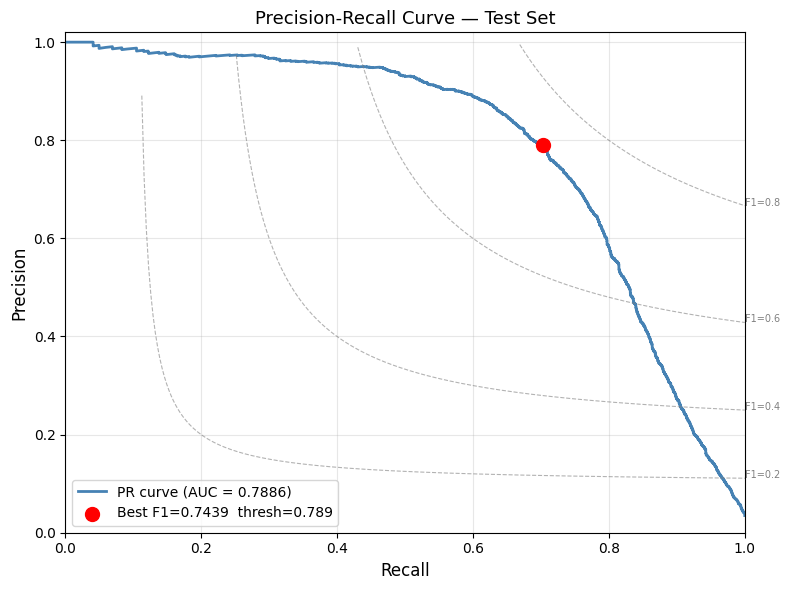

PR curve saved to models/xgboost/pr_curve.png


In [8]:
precision_pts, recall_pts, thresholds = precision_recall_curve(y_test, test_probs)

f1_scores = (
    2 * precision_pts[:-1] * recall_pts[:-1]
    / (precision_pts[:-1] + recall_pts[:-1] + 1e-8)
)
best_idx       = np.argmax(f1_scores)
best_thresh    = float(thresholds[best_idx])
best_f1        = float(f1_scores[best_idx])
test_recall    = float(recall_pts[best_idx])
test_precision = float(precision_pts[best_idx])

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_pts, precision_pts, color="steelblue", lw=2,
        label=f"PR curve (AUC = {test_pr:.4f})")
ax.scatter(test_recall, test_precision, color="red", zorder=5, s=100,
           label=f"Best F1={best_f1:.4f}  thresh={best_thresh:.3f}")

for f1_iso in [0.2, 0.4, 0.6, 0.8]:
    r_vals = np.linspace(0.01, 1.0, 300)
    p_vals = f1_iso * r_vals / (2 * r_vals - f1_iso + 1e-8)
    mask   = (p_vals >= 0) & (p_vals <= 1)
    ax.plot(r_vals[mask], p_vals[mask], "--", color="grey", lw=0.8, alpha=0.6)
    ax.annotate(f"F1={f1_iso}", xy=(r_vals[mask][-1], p_vals[mask][-1]),
                fontsize=7, color="grey")

ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Curve — Test Set", fontsize=13)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()

pr_curve_path = OUTPUT_DIR / "pr_curve.png"
plt.savefig(pr_curve_path, dpi=150)
plt.show()
print(f"PR curve saved to {pr_curve_path}")

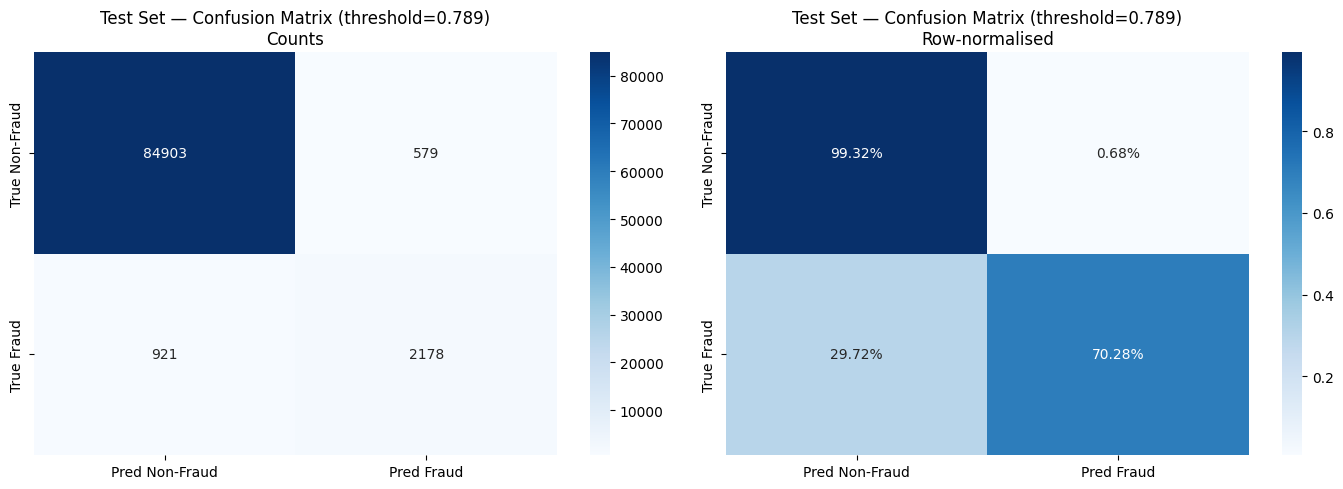


Classification Report (threshold=0.789):
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.99      0.99     85482
       Fraud       0.79      0.70      0.74      3099

    accuracy                           0.98     88581
   macro avg       0.89      0.85      0.87     88581
weighted avg       0.98      0.98      0.98     88581

Confusion matrix saved to models/xgboost/confusion_matrix.png


In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = (test_probs >= best_thresh).astype(int)
cm     = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0],
    xticklabels=['Pred Non-Fraud', 'Pred Fraud'],
    yticklabels=['True Non-Fraud', 'True Fraud']
)
axes[0].set_title(f'Test Set — Confusion Matrix (threshold={best_thresh:.3f})\nCounts')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2%',
    cmap='Blues',
    ax=axes[1],
    xticklabels=['Pred Non-Fraud', 'Pred Fraud'],
    yticklabels=['True Non-Fraud', 'True Fraud']
)
axes[1].set_title(f'Test Set — Confusion Matrix (threshold={best_thresh:.3f})\nRow-normalised')

plt.tight_layout()
cm_path = OUTPUT_DIR / 'confusion_matrix.png'
plt.savefig(cm_path, dpi=150)
plt.show()

report = classification_report(
    y_test,
    y_pred,
    target_names=['Non-Fraud', 'Fraud']
)
print(f"\nClassification Report (threshold={best_thresh:.3f}):\n{report}")

with open(OUTPUT_DIR / 'classification_report.txt', 'w') as f:
    f.write(f"Threshold: {best_thresh:.3f}\n\n{report}")

print(f"Confusion matrix saved to {cm_path}")

### Validation recall at best threshold

In [13]:
val_recall = recall_score(
    y_val,
    (val_probs >= best_thresh).astype(int),
    zero_division=0
)

print(f"\n{'='*50}")
print(f"  Final Results at best threshold = {best_thresh:.3f}")
print(f"{'='*50}")
print(f"  Test PR-AUC   : {test_pr:.4f}")
print(f"  Test F1       : {best_f1:.4f}")
print(f"  Test Recall   : {test_recall:.4f}")
print(f"  Test Precision: {test_precision:.4f}")
print(f"  Val  Recall   : {val_recall:.4f}")


  Final Results at best threshold = 0.789
  Test PR-AUC   : 0.7886
  Test F1       : 0.7439
  Test Recall   : 0.7028
  Test Precision: 0.7900
  Val  Recall   : 0.6864


# 8. Save Model

In [14]:
final_metrics = {
    "best_params": {
        k: v for k, v in params.items()
        if k not in ("eval_metric", "verbosity")
    },
    "val_pr_auc":      val_pr,
    "test_pr_auc":     test_pr,
    "best_thresh":     best_thresh,
    "test_f1":         best_f1,
    "test_recall":     test_recall,
    "test_precision":  test_precision,
    "val_recall":      val_recall,
}

metrics_path = OUTPUT_DIR / "final_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(final_metrics, f, indent=2)

print(f"\nFinal metrics saved to {metrics_path}")

# ── Save model ────────────────────────────────────────────────────────────────
model_path = OUTPUT_DIR / "xgb_fraud.ubj"
model.save_model(model_path)

print(f"\nModel saved → {model_path}")

print(f"\n{'='*50}")
print(f"  All outputs saved to: {OUTPUT_DIR}/")
print(f"    xgb_training_curves.png")
print(f"    pr_curve.png")
print(f"    confusion_matrix.png")
print(f"    classification_report.txt")
print(f"    training_log.csv")
print(f"    feature_importance.csv")
print(f"    test_predictions.csv")
print(f"    final_metrics.json")
print(f"    xgb_fraud.ubj")
print(f"{'='*50}")


Final metrics saved to models/xgboost/final_metrics.json

Model saved → models/xgboost/xgb_fraud.ubj

  All outputs saved to: models/xgboost/
    xgb_training_curves.png
    pr_curve.png
    confusion_matrix.png
    classification_report.txt
    training_log.csv
    feature_importance.csv
    test_predictions.csv
    final_metrics.json
    xgb_fraud.ubj
